# EN3160 Assignment 1 - Intensity Transformations and Neighborhood Filtering

##### **Name:** Perera U. I. Himal
##### **Index No:** 230486A 
##### **GitHub:** https://github.com/Isira-Himal-Perera/EN3160-Image-Processing-and-Computer-Vision/tree/main/assignment-01

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

## Question 1 - Piecewise-linear intensity transformation

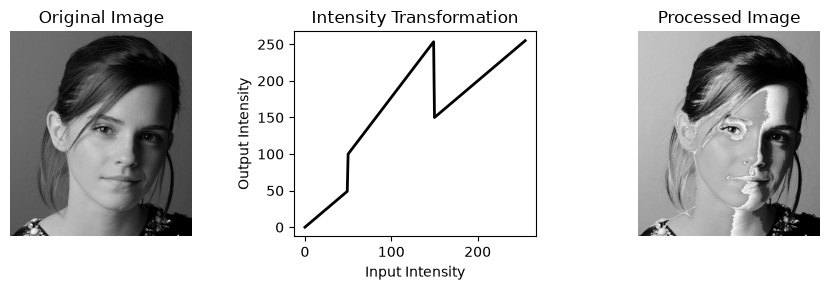

In [39]:
def intensity_transformation(im, breakpoints):
    input_values = breakpoints[:, 0]
    output_values = breakpoints[:, 1]
    transformed_im = np.interp(im.flatten(), input_values, output_values)
    return transformed_im.reshape(im.shape)

breakpoints = np.array([[0, 0],[50, 50],[50, 100],   [150, 255],[150, 150],[255, 255]], dtype=np.uint8)

x = np.arange(256, dtype=np.uint8)
y = intensity_transformation(x, breakpoints)
im = cv.imread('images/emma.jpg', cv.IMREAD_GRAYSCALE)
assert im is not None, "Image not found. Please check the path."
processed_im = intensity_transformation(im, breakpoints)

fig, ax = plt.subplots(1, 3, figsize=(9, 3))

ax[0].imshow(im, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].plot(x, y, 'black', linewidth=2)
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')
ax[1].set_title('Intensity Transformation')

ax[2].imshow(processed_im, cmap='gray')
ax[2].set_title('Processed Image')
ax[2].axis('off')

plt.tight_layout()
plt.show()


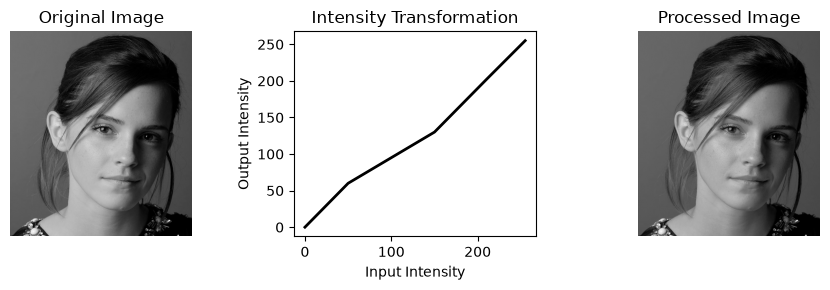

In [40]:
breakpoints = np.array([[0, 0], [50, 60], [150, 130], [200, 190], [255, 255]], dtype=np.uint8)

x = np.arange(256, dtype=np.uint8)
y = intensity_transformation(x, breakpoints)
im = cv.imread('images/emma.jpg', cv.IMREAD_GRAYSCALE)
processed_im = intensity_transformation(im, breakpoints)

fig, ax = plt.subplots(1, 3, figsize=(9, 3))
ax[0].imshow(im, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].plot(x, y, 'black', linewidth=2)
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')
ax[1].set_title('Intensity Transformation')
ax[2].imshow(processed_im, cmap='gray')
ax[2].set_title('Processed Image')
ax[2].axis('off')
plt.tight_layout()
plt.show()

### Discussion: Piecewise Linear Intensity Transformations

#### 1. Core Concept
Piecewise linear mapping adjusts image contrast by mapping input pixel values to output values using defined breakpoints[cite: 1].
* **Slope $m > 1$**: Expands dynamic range, increasing local contrast.
* **Slope $m < 1$**: Compresses dynamic range, lowering contrast in that tone range.

#### 2. Key Observations
* **Non-Monotonic Mapping (Given Curve)**: Abrupt drops in the curve invert mid-tone intensities, creating artificial edges (posterization) on smooth surfaces like skin tones.
* **Monotonic Mapping (Optimized Curve)**: A smoothly rising curve preserves natural tonal transitions, enhancing mid-tone clarity without visual artifacts.

## Question 2 - Accentuating white matter / gray matter

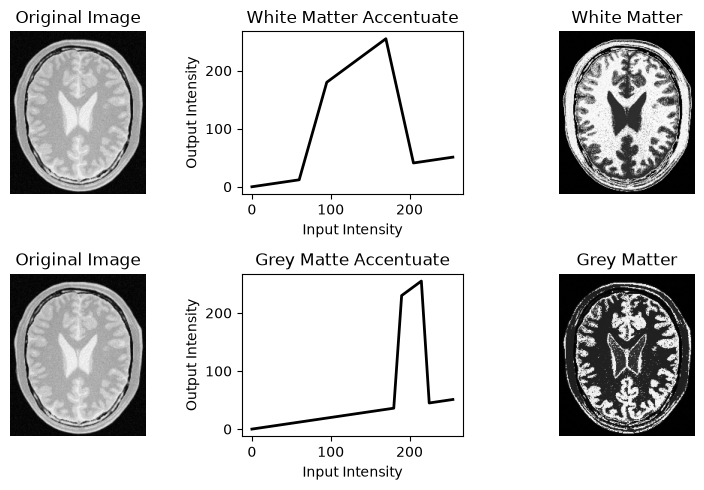

In [41]:
im = cv.imread('images/brain_proton_density_slice.png', cv.IMREAD_GRAYSCALE)
assert im is not None, "Image not found. Please check the path."

# White Accentuate
breakpoints_1 = np.array([[0, 0], [60, 12], [95, 180], [170, 255],[205, 41],[255, 51]], dtype=np.uint8)
y_1 = intensity_transformation(x, breakpoints_1)
processed_im = intensity_transformation(im, breakpoints_1)

# Grey Accentuate
breakpoints_2 = np.array([[0, 0], [180, 36],[190, 230],[215, 255],[225, 45],[255, 51]], dtype=np.uint8)
y_2 = intensity_transformation(x, breakpoints_2)
processed_im_2 = intensity_transformation(im, breakpoints_2)

fig, ax = plt.subplots(2, 3, figsize=(8, 5))
ax[0, 0].imshow(im, cmap='gray')
ax[0, 0].set_title('Original Image')
ax[0, 0].axis('off')
ax[0, 1].plot(x, y_1, 'black', linewidth=2)
ax[0, 1].set_xlabel('Input Intensity')
ax[0, 1].set_ylabel('Output Intensity')
ax[0, 1].set_title('White Matter Accentuate')
ax[0, 2].imshow(processed_im, cmap='gray')
ax[0, 2].set_title('White Matter')
ax[0, 2].axis('off')
ax[1, 0].imshow(im, cmap='gray')
ax[1, 0].set_title('Original Image')
ax[1, 0].axis('off')
ax[1, 1].plot(x, y_2, 'black', linewidth=2)
ax[1, 1].set_xlabel('Input Intensity')
ax[1, 1].set_ylabel('Output Intensity')
ax[1, 1].set_title('Grey Matte Accentuate')
ax[1, 2].imshow(processed_im_2, cmap='gray')
ax[1, 2].set_title('Grey Matter')
ax[1, 2].axis('off')
plt.tight_layout()
plt.show()

## Question 3 - Gamma correction on the L plane 

### Discussion: Accentuation of White and Gray Matter

#### 1. Core Concept
* **Intensity Slicing**: Targeted piecewise linear mapping isolates specific gray-level bands corresponding to distinct anatomical tissues (white matter vs. gray matter) while dampening non-relevant intensity ranges[cite: 1].

#### 2. Key Observations
* **White Matter Accentuation**: 
  * Map peak is centered around the mid-tone range ($[95, 180]$ mapped to $[180, 255]$).
  * Brightens internal cerebral structures while suppressing surrounding background tissues.
* **Gray Matter Accentuation**: 
  * Map peak is narrowly targeted at higher mid-tone values ($[190, 215]$ mapped to $[230, 255]$).
  * Highlights the outer cortical rim and basal structures, darkening CSF and white matter regions.

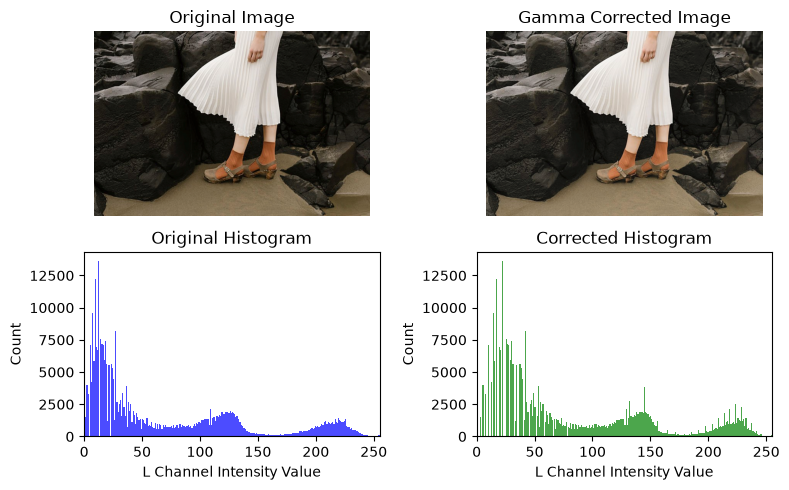

In [42]:
def gamma_correction(im_lab, gamma):
    '''Apply gamma correction to the image in L*a*b color space.'''
    l_channel, a_channel, b_channel = cv.split(im_lab)
    l_channel = np.power(l_channel / 255.0, gamma) * 255.0
    l_channel = np.clip(l_channel, 0, 255).astype(np.uint8)
    corrected_im_lab = cv.merge((l_channel, a_channel, b_channel))
    return corrected_im_lab

im = cv.imread('images/highlights_and_shadows.jpg')
assert im is not None, "Image not found. Please check the path."
im_lab = cv.cvtColor(im, cv.COLOR_BGR2Lab)

# Apply gamma correction
gamma = 0.8
corrected_im_lab = gamma_correction(im_lab, gamma)

# Display the original and corrected images alongside their histograms
fig, ax = plt.subplots(2, 2, figsize=(8, 5))
ax[0, 0].imshow(cv.cvtColor(im_lab, cv.COLOR_Lab2RGB))
ax[0, 0].set_title('Original Image')
ax[0, 0].axis('off')
ax[0, 1].imshow(cv.cvtColor(corrected_im_lab, cv.COLOR_Lab2RGB))
ax[0, 1].set_title('Gamma Corrected Image')
ax[0, 1].axis('off')
ax[1, 0].hist(cv.split(im_lab)[0].ravel(), bins=256, color='blue', alpha=0.7)
ax[1, 0].set_title('Original Histogram')
ax[1, 0].set_xlim(0, 255)
ax[1, 0].set_xlabel('L Channel Intensity Value')
ax[1, 0].set_ylabel('Count')
ax[1, 1].hist(cv.split(corrected_im_lab)[0].ravel(), bins=256, color='green', alpha=0.7)
ax[1, 1].set_title('Corrected Histogram')
ax[1, 1].set_xlim(0, 255)
ax[1, 1].set_xlabel('L Channel Intensity Value')
ax[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Discussion: Gamma Correction in $L^*a^*b^*$ Space

#### 1. Core Concept
* **Perceptual Luminance Adjustment**: Gamma correction ($s = c \cdot r^\gamma$) is applied strictly to the $L^*$ (lightness) channel in $L^*a^*b^*$ space.
* **Color Preservation**: Modifying $L^*$ decoupled from $a^*$ and $b^*$ adjusts brightness and contrast without distorting hue or chromatic saturation.

#### 2. Key Observations
* **Gamma Value ($\gamma = 0.8$)**: Applying $\gamma < 1$ expands the shadow region and increases overall lightness.
* **Histogram Shift**: Pixel intensity counts shift toward higher lightness values (rightward shift), revealing previously obscured details in underexposed shadow regions (e.g., dark rocks).

## Question 4 - Vibrance enhancement on the Saturation plane

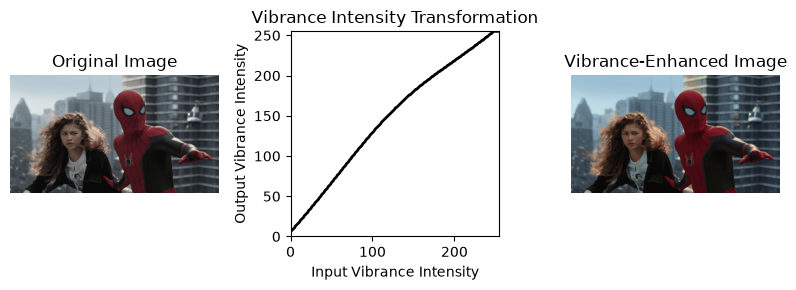

In [43]:
im = cv.imread('images/spider.png')
assert im is not None, "Image not found. Please check the path."

f = lambda x, a, sigma=70: np.minimum(x + a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2)), 255).astype(np.uint8)
im_hsv = cv.cvtColor(im, cv.COLOR_BGR2HSV)
h_channel, s_channel, v_channel = cv.split(im_hsv)
s_channel_enhanced = f(s_channel, a=0.25)  # Adjust 'a' as needed
im_enhanced = cv.merge([h_channel, s_channel_enhanced, v_channel])

fig, ax = plt.subplots(1, 3, figsize=(8, 3))
ax[0].imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].plot(np.arange(256), f(np.arange(256), a=0.25), 'black', linewidth=2)
ax[1].set_xlabel('Input Vibrance Intensity')
ax[1].set_ylabel('Output Vibrance Intensity')
ax[1].set_title('Vibrance Intensity Transformation')
ax[1].set_xlim(0, 255)
ax[1].set_ylim(0, 255)
ax[2].imshow(cv.cvtColor(im_enhanced, cv.COLOR_HSV2RGB))
ax[2].set_title('Vibrance-Enhanced Image')
ax[2].axis('off')
plt.tight_layout()
plt.show()

### Discussion: Vibrance Enhancement on the Saturation Plane

#### 1. Core Concept
* **Selective Saturation Boosting**: Vibrance applies a Gaussian-weighted boost centered around mid-range saturation ($x = 128$) via $f(x) = \min\left(x + a \cdot 128 e^{-\frac{(x-128)^2}{2\sigma^2}}, 255\right)$[cite: 1].
* **Over-saturation Protection**: Unlike uniform saturation scaling, this non-linear curve protects already highly saturated colors from clipping while boosting muted tones[cite: 1].

#### 2. Key Observations
* **Parameter Choice ($a = 0.25, \sigma = 70$)**: Provides a balanced boost peaked at mid-level saturations without introducing severe color distortion or harsh artifacts[cite: 1].
* **Visual Result**: Muted background tones and skin mid-tones achieve richer, more natural color depth while high-saturation regions (such as the red suit) remain stable without highlight clipping[cite: 1].

## Question 5 - Histogram equalization from scratch

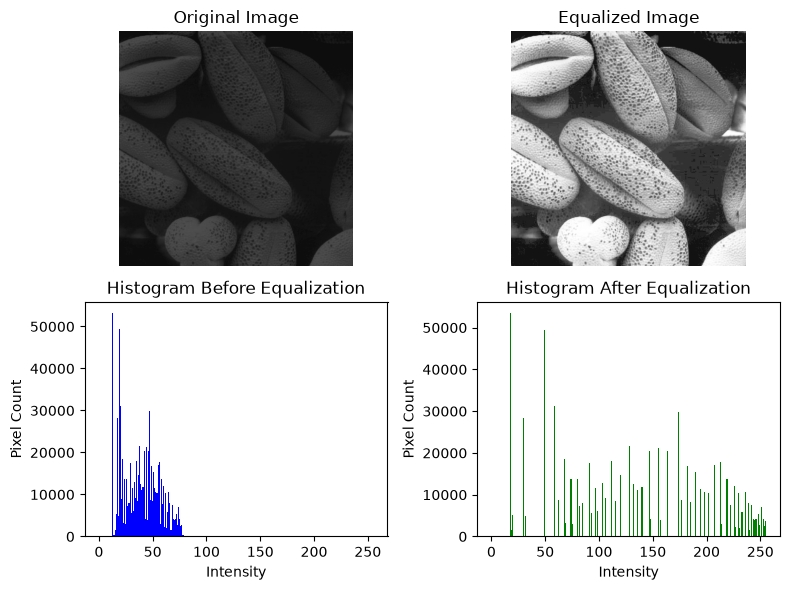

In [44]:

'''Write a function of your own to carry out histogram equalization on the image shown in Fig. 5. Show the histograms before and after equalization'''

def histogram_equalization(im, flag=cv.IMREAD_GRAYSCALE):
    # Calculate the histogram

    n_k = np.bincount(im.flatten(), minlength=256)
    n_k_sum = np.cumsum(n_k)
    n = im.size

    # Calculate the transformation function
    f = np.round(n_k_sum / (n) * 255).astype(np.uint8)

    # Apply the transformation to the image
    equalized_im = f[im]

    return equalized_im

im = cv.imread('images/shells.tif')
assert im is not None, "Image not found. Please check the path."
im_equalized = histogram_equalization(im)

fig, ax = plt.subplots(2, 2, figsize=(8, 6))
ax[0, 0].imshow(im, cmap='gray')
ax[0, 0].set_title('Original Image')
ax[0, 0].axis('off')
ax[0, 1].imshow(im_equalized, cmap='grey')
ax[0, 1].set_title('Equalized Image')
ax[0, 1].axis('off')    

hist_before = np.bincount(im.ravel(), minlength=256)
hist_after = np.bincount(im_equalized.ravel(), minlength=256)

ax[1, 0].bar(np.arange(256), hist_before, color='blue', width=1)
ax[1, 0].set_title('Histogram Before Equalization')
ax[1, 0].set_xlabel('Intensity')
ax[1, 0].set_ylabel('Pixel Count')
ax[1, 1].bar(np.arange(256), hist_after, color='green', width=1)
ax[1, 1].set_title('Histogram After Equalization')
ax[1, 1].set_xlabel('Intensity')
ax[1, 1].set_ylabel('Pixel Count')
plt.tight_layout()
plt.show()

### Discussion: Global Histogram Equalization

#### 1. Core Concept
* **Cumulative Distribution Mapping**: Maps input intensity $r_k$ using its cumulative density function (CDF): $s_k = \mathrm{round}\left(\frac{(L-1)}{N} \sum_{j=0}^{k} n_j\right)$.
* **Global Dynamic Range Expansion**: Spreads out concentrated intensity values across the entire allowable 8-bit spectrum $[0, 255]$, maximizing overall global image contrast.

#### 2. Key Observations
* **Histogram Redistribution**: The highly compressed low-intensity histogram ($[15, 80]$) is stretched across $[20, 255]$, creating distinct gaps between active intensity bins due to discrete quantization.
* **Visual Result**: Unveils hidden surface textures and structural details on the low-contrast pollen grains, significantly improving visibility across darker regions.

## Question 6 - Histogram equalization of the foreground only

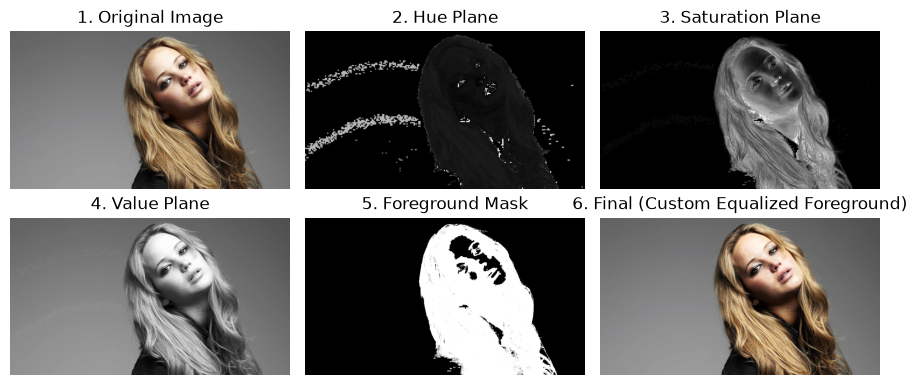

In [45]:
def custom_histogram_equalization(foreground, mask=None):
    L = 256  

    if mask is not None:
        fg_pixels = foreground[mask > 0]
        n = fg_pixels.size
        if n == 0:
            return foreground.copy()
        
        n_k = np.bincount(fg_pixels, minlength=L)
    else:
        n = foreground.size
        n_k = np.bincount(foreground.flatten(), minlength=L)

    n_k_sum = np.cumsum(n_k)
    f = np.round(((L - 1) / n) * n_k_sum).astype(np.uint8)
    fg_equalized = f[foreground]

    return fg_equalized

im = cv.imread('images/jeniffer.jpg')
assert im is not None, "Image not found. Please check the path."

im_hsv = cv.cvtColor(im, cv.COLOR_BGR2HSV)
h_channel, s_channel, v_channel = cv.split(im_hsv)
_, mask = cv.threshold(s_channel, 50, 255, cv.THRESH_BINARY)
mask_inv = cv.bitwise_not(mask)

background = cv.bitwise_and(im, im, mask=mask_inv)
foreground = cv.bitwise_and(im, im, mask=mask)

fg_hsv = cv.cvtColor(foreground, cv.COLOR_BGR2HSV)
fg_h, fg_s, fg_v = cv.split(fg_hsv)
fg_v_equalized = custom_histogram_equalization(fg_v, mask=mask)

fg_hsv_equalized = cv.merge([fg_h, fg_s, fg_v_equalized])
equalized_foreground = cv.cvtColor(fg_hsv_equalized, cv.COLOR_HSV2BGR)
equalized_foreground = cv.bitwise_and(equalized_foreground, equalized_foreground, mask=mask)

final_result = cv.add(background, equalized_foreground)

fig, ax = plt.subplots(2, 3, figsize=(9, 4))
ax[0, 0].imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
ax[0, 0].set_title('1. Original Image')
ax[0, 0].axis('off')
ax[0, 1].imshow(h_channel, cmap='gray')
ax[0, 1].set_title('2. Hue Plane')
ax[0, 1].axis('off')
ax[0, 2].imshow(s_channel, cmap='gray')
ax[0, 2].set_title('3. Saturation Plane')
ax[0, 2].axis('off')
ax[1, 0].imshow(v_channel, cmap='gray')
ax[1, 0].set_title('4. Value Plane')
ax[1, 0].axis('off')
ax[1, 1].imshow(mask, cmap='gray')
ax[1, 1].set_title('5. Foreground Mask')
ax[1, 1].axis('off')
ax[1, 2].imshow(cv.cvtColor(final_result, cv.COLOR_BGR2RGB))
ax[1, 2].set_title('6. Final (Custom Equalized Foreground)')
ax[1, 2].axis('off')
plt.tight_layout()
plt.show()

### Discussion: Foreground-Specific Histogram Equalization

#### 1. Core Concept
* **Mask-Guided Processing**: By thresholding the saturation plane, a binary foreground mask isolates the subject (hair, face, torso) from the neutral background[cite: 1].
* **Selective Value Equalization**: Equalizing only the $V$ (Value) channel within masked foreground pixels enhances local detail and contrast on the subject without distorting skin tones or affecting the uniform background[cite: 1].

#### 2. Key Observations
* **plane Selection**: The Saturation plane provides clear separation between the colorful foreground subject and the low-saturation gray background, making simple binary thresholding highly effective[cite: 1].
* **Visual Result**: Highlights facial structure and hair texture while keeping the studio background unaltered, preventing noise amplification or dynamic range washing in background regions[cite: 1].

## Question 7 - Sobel filtering three ways

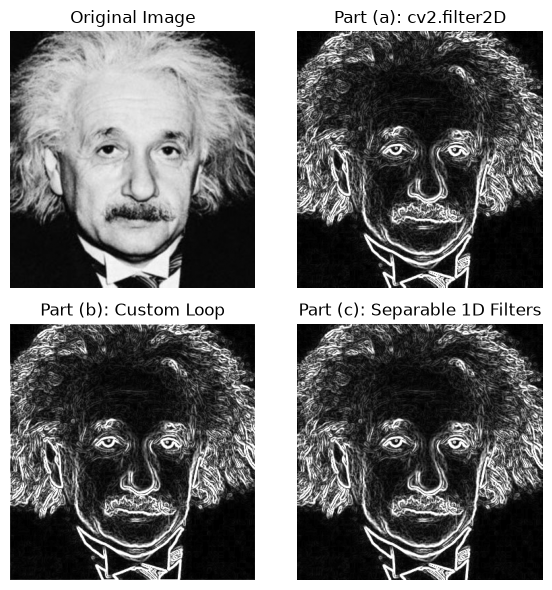

In [46]:
im = cv.imread('images/einstein.png', cv.IMREAD_GRAYSCALE)
assert im is not None, "Image not found. Please check the path."

# Part (a)
sobel_x = np.array([[-1,  0,  1],[-2,  0,  2],[-1,  0,  1]], dtype=np.float32)

sobel_y = np.array([[-1, -2, -1],[ 0,  0,  0],[ 1,  2,  1]], dtype=np.float32)

grad_x_a = cv.filter2D(im, cv.CV_64F, sobel_x)
grad_y_a = cv.filter2D(im, cv.CV_64F, sobel_y)

im_sobel_a = np.sqrt(grad_x_a**2 + grad_y_a**2)
im_sobel_a = cv.convertScaleAbs(im_sobel_a)

# Part(b)
def custom_sobel_filter(image):
    H, W = image.shape
    
    sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float64)
    sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float64)
    
    # Pad image to handle borders (zero-padding)
    padded_img = np.pad(image, ((1, 1), (1, 1)), mode='constant', constant_values=0)
    
    grad_x = np.zeros((H, W), dtype=np.float64)
    grad_y = np.zeros((H, W), dtype=np.float64)
    
    # Perform 2D cross-correlation / convolution manually
    for i in range(H):
        for j in range(W):
            region = padded_img[i:i+3, j:j+3]
            grad_x[i, j] = np.sum(region * sobel_x)
            grad_y[i, j] = np.sum(region * sobel_y)
            
    magnitude = np.sqrt(grad_x**2 + grad_y**2)
    return np.uint8(np.clip(magnitude, 0, 255))

im_sobel_b = custom_sobel_filter(im)

# Part (c)
v_gaussian = np.array([[1], [2], [1]], dtype=np.float32)      
h_diff     = np.array([[1, 0, -1]], dtype=np.float32)         

v_diff     = np.array([[1], [0], [-1]], dtype=np.float32)     
h_gaussian = np.array([[1, 2, 1]], dtype=np.float32)          

grad_x_c = cv.sepFilter2D(im, cv.CV_64F, h_diff, v_gaussian)
grad_y_c = cv.sepFilter2D(im, cv.CV_64F, h_gaussian, v_diff)

im_sobel_c = np.sqrt(grad_x_c**2 + grad_y_c**2)
im_sobel_c = cv.convertScaleAbs(im_sobel_c)


fig, ax = plt.subplots(2, 2, figsize=(6, 6))
ax[0, 0].imshow(im, cmap='gray')
ax[0, 0].set_title('Original Image')
ax[0, 0].axis('off')
ax[0, 1].imshow(im_sobel_a, cmap='gray')
ax[0, 1].set_title('Part (a): cv2.filter2D')
ax[0, 1].axis('off')
ax[1, 0].imshow(im_sobel_b, cmap='gray')
ax[1, 0].set_title('Part (b): Custom Loop')
ax[1, 0].axis('off')
ax[1, 1].imshow(im_sobel_c, cmap='gray')
ax[1, 1].set_title('Part (c): Separable 1D Filters')
ax[1, 1].axis('off')

plt.tight_layout()
plt.show()

### Discussion: Sobel Edge Detection Methods

#### 1. Core Concept
* **Gradient-Based Edge Extraction**: The Sobel operator approximates spatial derivatives along the $x$ and $y$ axes to highlight high-frequency intensity transitions (edges).
* **Filter Separability**: The 2D Sobel kernel is rank-1 and mathematically separable into 1D smoothing and derivative vectors:
  $$\begin{bmatrix} 1 & 0 & -1 \\ 2 & 0 & -2 \\ 1 & 0 & -1 \end{bmatrix} = \begin{bmatrix} 1 \\ 2 \\ 1 \end{bmatrix} * \begin{bmatrix} 1 & 0 & -1 \end{bmatrix}$$

#### 2. Key Observations
* **Equivalence of Implementations**: All three approaches—built-in `cv.filter2D`, custom 2D spatial convolution, and sequential 1D separable filtering—produce identical gradient magnitude maps.
* **Computational Efficiency**: Applying two 1D passes reduces operations per pixel from $O(K^2)$ to $O(2K)$ relative to direct 2D spatial convolution, improving processing speed for larger kernels.

## Question 8 - Zooming with nearest-neighbour and bilinear interpolation

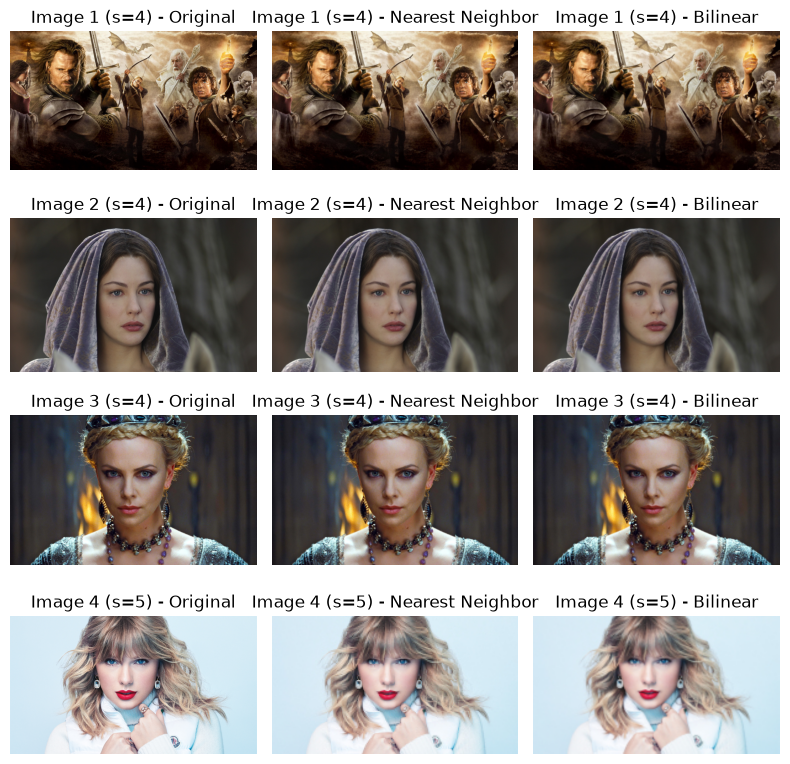

In [47]:
# Interpolation Functions 
def nearest_neighbor(im, s):
    H, W, C = im.shape
    H_NEW = int(H * s)
    W_NEW = int(W * s)
    
    im_interpolated = np.zeros((H_NEW, W_NEW, C), dtype=im.dtype)
    src_x_all = (np.arange(W_NEW) // s).astype(int)
    
    for y in range(H_NEW):
        src_y = int(y // s)
        for x in range(W_NEW):
            src_x = src_x_all[x]
            im_interpolated[y, x] = im[src_y, src_x]

    return im_interpolated


def biliniear_interpolation(im, s):
    H, W, C = im.shape
    H_NEW = int(H * s)
    W_NEW = int(W * s)
    
    im_float = im.astype(np.float32)
    im_interpolated = np.zeros((H_NEW, W_NEW, C), dtype=np.float32)
    
    x1_all = (np.arange(W_NEW) // s).astype(int)
    x2_all = np.minimum(x1_all + 1, W - 1)
    i1_all = (np.arange(W_NEW) % s) / s
    i2_all = 1.0 - i1_all

    for y in range(H_NEW):
        y1 = int(y // s)
        y2 = min(y1 + 1, H - 1)
        j1 = (y % s) / s
        j2 = 1.0 - j1
        
        row1 = im_float[y1]
        row2 = im_float[y2]
        
        for x in range(W_NEW):
            x1 = x1_all[x]
            x2 = x2_all[x]
            i1 = i1_all[x]
            i2 = i2_all[x]
            
            im_interpolated[y, x] = (row1[x1] * (j2 * i2) + row1[x2] * (j2 * i1) + row2[x1] * (j1 * i2) + row2[x2] * (j1 * i1))

    return np.clip(im_interpolated, 0, 255).astype(im.dtype)

# Load Images with Asserts 
im_1 = cv.imread('images/a1q5images/im01small.png')
assert im_1 is not None, "Image not found. Please check the path."
im_1_original = cv.imread('images/a1q5images/im01.png')
assert im_1_original is not None, "Image not found. Please check the path."
im_1_nearest_neighbor = nearest_neighbor(im_1, 4)
im_1_biliniear = biliniear_interpolation(im_1, 4)

im_2 = cv.imread('images/a1q5images/im02small.png')
assert im_2 is not None, "Image not found. Please check the path."
im_2_original = cv.imread('images/a1q5images/im02.png')
assert im_2_original is not None, "Image not found. Please check the path."
im_2_nearest_neighbor = nearest_neighbor(im_2, 4)
im_2_biliniear = biliniear_interpolation(im_2, 4)

im_3 = cv.imread('images/a1q5images/im03small.png')
assert im_3 is not None, "Image not found. Please check the path."
im_3_original = cv.imread('images/a1q5images/im03.png')
assert im_3_original is not None, "Image not found. Please check the path."
im_3_nearest_neighbor = nearest_neighbor(im_3, 4)
im_3_biliniear = biliniear_interpolation(im_3, 4)

im_4 = cv.imread('images/a1q5images/taylor_small.jpg')
assert im_4 is not None, "Image not found. Please check the path."
im_4_original = cv.imread('images/a1q5images/taylor.jpg')
assert im_4_original is not None, "Image not found. Please check the path."
im_4_nearest_neighbor = nearest_neighbor(im_4, 5)
im_4_biliniear = biliniear_interpolation(im_4, 5)


# 3. Plot 4x3 Grid 
data = [
    ("Image 1 (s=4)", im_1_original, im_1_nearest_neighbor, im_1_biliniear),
    ("Image 2 (s=4)", im_2_original, im_2_nearest_neighbor, im_2_biliniear),
    ("Image 3 (s=4)", im_3_original, im_3_nearest_neighbor, im_3_biliniear),
    ("Image 4 (s=5)", im_4_original, im_4_nearest_neighbor, im_4_biliniear),
]

fig, axes = plt.subplots(4, 3, figsize=(8, 8))

for row_idx, (name, orig, nn, bl) in enumerate(data):
    axes[row_idx, 0].imshow(cv.cvtColor(orig, cv.COLOR_BGR2RGB))
    axes[row_idx, 0].set_title(f"{name} - Original")
    axes[row_idx, 0].axis('off')

    axes[row_idx, 1].imshow(cv.cvtColor(nn, cv.COLOR_BGR2RGB))
    axes[row_idx, 1].set_title(f"{name} - Nearest Neighbor")
    axes[row_idx, 1].axis('off')

    axes[row_idx, 2].imshow(cv.cvtColor(bl, cv.COLOR_BGR2RGB))
    axes[row_idx, 2].set_title(f"{name} - Bilinear")
    axes[row_idx, 2].axis('off')

plt.tight_layout()
plt.show()

In [48]:
def compute_ssd_per_pixel(im1, im2):
    """
    Computes Sum of Squared Differences (SSD) normalized per pixel element.
    Crops images to matching dimensions if there are off-by-one size differences.
    """
    H = min(im1.shape[0], im2.shape[0])
    W = min(im1.shape[1], im2.shape[1])
    
    # Crop both images to matching size
    img1_crop = im1[:H, :W].astype(np.float64)
    img2_crop = im2[:H, :W].astype(np.float64)
    
    # Calculate average squared difference per pixel element across all channels
    ssd_per_pixel = np.mean((img1_crop - img2_crop) ** 2)
    return ssd_per_pixel

ssd_per_pixel_results = np.zeros((4, 2), dtype=np.float64)

# Image 1 (s=4)
ssd_per_pixel_results[0, 0] = compute_ssd_per_pixel(im_1_original, im_1_nearest_neighbor)
ssd_per_pixel_results[0, 1] = compute_ssd_per_pixel(im_1_original, im_1_biliniear)
# Image 2 (s=4)
ssd_per_pixel_results[1, 0] = compute_ssd_per_pixel(im_2_original, im_2_nearest_neighbor)
ssd_per_pixel_results[1, 1] = compute_ssd_per_pixel(im_2_original, im_2_biliniear)
# Image 3 (s=4)
ssd_per_pixel_results[2, 0] = compute_ssd_per_pixel(im_3_original, im_3_nearest_neighbor)
ssd_per_pixel_results[2, 1] = compute_ssd_per_pixel(im_3_original, im_3_biliniear)
# Taylor (s=5)
ssd_per_pixel_results[3, 0] = compute_ssd_per_pixel(im_4_original, im_4_nearest_neighbor)
ssd_per_pixel_results[3, 1] = compute_ssd_per_pixel(im_4_original, im_4_biliniear)

image_names = ["Image 01 (s=4)", "Image 02 (s=4)", "Image 03 (s=4)", "Image 04 (s=5)"]
print("=" * 68)
print(f"{'Image':<18} | {'SSD/pixel (Nearest)':<22} | {'SSD/pixel (Bilinear)':<20}")
print("=" * 68)
for row in range(4):
    nn_val = ssd_per_pixel_results[row, 0]
    bl_val = ssd_per_pixel_results[row, 1]
    print(f"{image_names[row]:<18} | {nn_val:<22.4f} | {bl_val:<20.4f}")

print("=" * 68)

Image              | SSD/pixel (Nearest)    | SSD/pixel (Bilinear)
Image 01 (s=4)     | 136.2690               | 200.2451            
Image 02 (s=4)     | 26.4461                | 48.9607             
Image 03 (s=4)     | 67.5817                | 98.0623             
Image 04 (s=5)     | 238.0281               | 285.2137            


### Discussion: Image Zooming and Interpolation

#### 1. Core Concept
* **Spatial Upsampling**: Zooming increases image dimensions by mapping destination coordinates back to source pixel coordinates using scaling factor $s$[cite: 1].
* **Interpolation Techniques**:
  * **Nearest-Neighbor**: Selects the closest intensity value without averaging, preserving sharp pixel transitions at the cost of blocky artifacts.
  * **Bilinear Interpolation**: Computes a weighted average of the 2x2 neighboring pixels based on relative distances, producing smoother spatial transitions.

#### 2. Key Observations
* **Visual Quality**: Bilinear interpolation produces visually smoother gradients and eliminates pixelation along diagonal edges compared to nearest-neighbor upscaling.
* **Quantification (SSD Metric)**: Bilinear interpolation yields higher per-pixel Sum of Squared Differences (SSD) relative to the ground truth original images because the linear blending introduces a slight blurring effect, whereas original high-frequency details remain sharp.

## Question 9 — GrabCut segmentation and background blur

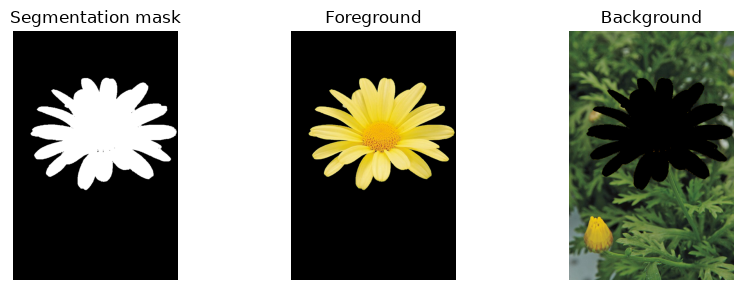

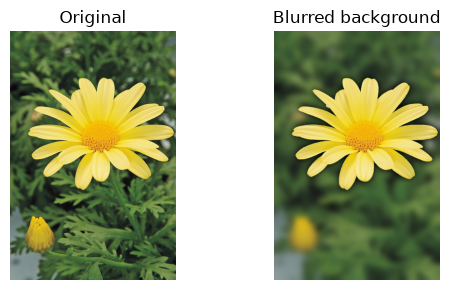

In [49]:
im = cv.imread("images/daisy.jpg")
assert im_3_original is not None, "Image not found. Please check the path."
H, W, C = im.shape

mask = np.zeros((H, W), np.uint8)
bgd_model = np.zeros((1, 65), np.float64)
fgd_model = np.zeros((1, 65), np.float64)
rect = (int(W * 0.03), int(H * 0.1), int(W * 0.97), int(H * 0.6))

cv.grabCut(im, mask, rect, bgd_model, fgd_model, 5, cv.GC_INIT_WITH_RECT)
binary_mask = np.where((mask == 2) | (mask == 0), 0, 1).astype(np.uint8)
foreground = im * binary_mask[:, :, None]
background = im * (1 - binary_mask[:, :, None])

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(binary_mask, cmap='gray'); axes[0].set_title("Segmentation mask"); axes[0].axis('off')
axes[1].imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB)); axes[1].set_title("Foreground"); axes[1].axis('off')
axes[2].imshow(cv.cvtColor(background, cv.COLOR_BGR2RGB)); axes[2].set_title("Background"); axes[2].axis('off')
plt.tight_layout(); plt.show()

def blur_background(img, binary_mask, ksize=31):
    bg_only = img * (1 - binary_mask[:, :, None])
    blurred_bg = cv.GaussianBlur(bg_only, (ksize, ksize), 0)
    fg = img * binary_mask[:, :, None]
    return (fg + blurred_bg * (1 - binary_mask[:, :, None])).astype(np.uint8)

enhanced = blur_background(im, binary_mask, ksize=71)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB)); axes[0].set_title("Original"); axes[0].axis('off')
axes[1].imshow(cv.cvtColor(enhanced, cv.COLOR_BGR2RGB)); axes[1].set_title("Blurred background"); axes[1].axis('off')
plt.tight_layout()
plt.show()

### Discussion: GrabCut Segmentation and Background Blurring

#### 1. Core Concept
* **GrabCut Foreground Extraction**: GrabCut estimates color distributions of the foreground and background using Gaussian Mixture Models (GMMs) initialized via a user-defined bounding box (`cv.GC_INIT_WITH_RECT`). An iterative Graph Cut optimization solves the min-cut problem to separate the main subject (`cv.GC_FGD` / `cv.GC_PR_FGD`) from the background.
* **Synthetic Depth-of-Field (Bokeh Effect)**: Applying a 2D Gaussian Kernel (e.g., $71 \times 71$) exclusively to the background pixels simulates a shallow depth of field, visually isolating the sharply segmented foreground object.

#### 2. Key Observations
* **Segmentation Accuracy**: The GMM effectively separates the distinct yellow daisy petals from the surrounding green foliage based on color distributions, yielding a clean binary mask.
* **Edge Halo Artifacts**: Gaussian blurring the masked background image directly causes a slight dark halo along the foreground boundary. This occurs because zero-valued (black) pixels in the masked foreground area bleed into the blurred background edges during convolution.

## Question 10 — Bilateral filtering

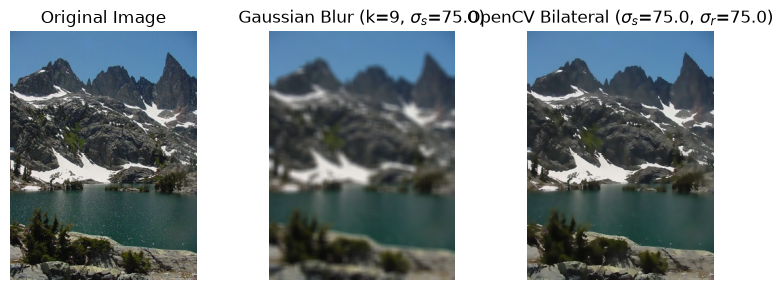

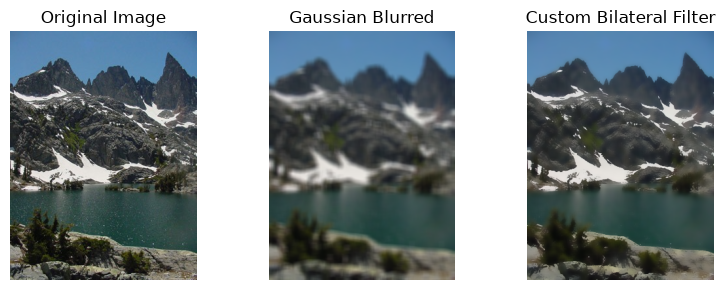

Normalized SSD between the two images: 2.884500e+01


In [ ]:
im = cv.imread('images/mountains.jpeg')  # Replace with your image path
assert im is not None, "Image not found. Please check the path."
H, W, C = im.shape

d = 9
sigma_s = 75.0
sigma_r = 75.0

# OpenCV Filters 
gaussian_img = cv.GaussianBlur(im, (d, d), sigmaX=sigma_s, sigmaY=sigma_s)
cv_bilateral = cv.bilateralFilter(im, d=d, sigmaColor=sigma_r, sigmaSpace=sigma_s)

# Original vs Gaussian vs OpenCV Bilateral
fig, axes = plt.subplots(1, 3, figsize=(8, 3))
axes[0].imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB)); axes[0].set_title("Original Image"); axes[0].axis('off')
axes[1].imshow(cv.cvtColor(gaussian_img, cv.COLOR_BGR2RGB))
axes[1].set_title(rf"Gaussian Blur (k={d}, $\sigma_s$={sigma_s})")
axes[1].axis('off')
axes[2].imshow(cv.cvtColor(cv_bilateral, cv.COLOR_BGR2RGB)) 
axes[2].set_title(rf"OpenCV Bilateral ($\sigma_s$={sigma_s}, $\sigma_r$={sigma_r})"); axes[2].axis('off')
plt.tight_layout(); plt.show()


# Custom Bilateral Filter & SSD Helper ---
def compute_ssd(im1, im2):
    """Computes Mean Squared Difference (SSD per pixel) between two images."""
    return np.mean((im1.astype(np.float64) - im2.astype(np.float64)) ** 2)


def custom_bilateral_filter(im, d=9, sigma_s=75.0, sigma_r=75.0):
    H, W, C = im.shape
    radius = d // 2
    
    padded = np.pad(im, ((radius, radius), (radius, radius), (0, 0)), mode='edge').astype(np.float64)
    im_float = im.astype(np.float64)
    out = np.zeros_like(im_float)

    y_grid, x_grid = np.mgrid[-radius:radius+1, -radius:radius+1]
    spatial_weights = np.exp(-(x_grid**2 + y_grid**2) / (2 * (sigma_s ** 2)))

    for r in range(H):
        for c in range(W):
            region = padded[r:r + d, c:c + d]
            center_val = im_float[r, c]

            diff = region - center_val
            range_dist_sq = np.sum(diff ** 2, axis=2)
            range_weights = np.exp(-range_dist_sq / (2 * (sigma_r ** 2)))

            total_weights = spatial_weights * range_weights
            w_p = np.sum(total_weights)

            out[r, c] = np.sum(region * total_weights[:, :, None], axis=(0, 1)) / w_p

    return np.clip(out, 0, 255).astype(im.dtype)


# Custom Bilateral Filter Execution & Comparison ---
custom_bilateral = custom_bilateral_filter(im, d=d, sigma_s=sigma_s, sigma_r=sigma_r)
ssd = compute_ssd(custom_bilateral, cv_bilateral)

# Original vs Gaussian vs Custom Bilateral
fig, axes = plt.subplots(1, 3, figsize=(8, 3))
axes[0].imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB)) 
axes[0].set_title("Original Image"); axes[0].axis('off')
axes[1].imshow(cv.cvtColor(gaussian_img, cv.COLOR_BGR2RGB))
axes[1].set_title("Gaussian Blurred"); axes[1].axis('off')
axes[2].imshow(cv.cvtColor(custom_bilateral, cv.COLOR_BGR2RGB))
axes[2].set_title("Custom Bilateral Filter"); axes[2].axis('off')
plt.tight_layout(); plt.show()

print(f"Normalized SSD between the two images: {ssd:.6e}")

### Discussion: Bilateral Filtering and Edge-Preserving Smoothing

#### 1. Core Concept
* **Dual Gaussian Kernel Combination**: Bilateral filtering smooths images while preserving sharp edges by combining spatial domain weighting $W_s$ and intensity range weighting $W_r$:
  $$I^{\text{filtered}}(p) = \frac{1}{W_p} \sum_{q \in S} I(q) \cdot \exp\left(-\frac{\|p - q\|^2}{2\sigma_s^2}\right) \cdot \exp\left(-\frac{\|I(p) - I(q)\|^2}{2\sigma_r^2}\right)$$
* **Range Gaussian Penalty**: Neighbors with intensity differences exceeding $\sigma_r$ receive exponentially smaller weights, preventing smoothing across prominent object boundaries.

#### 2. Key Observations
* **Bilateral vs. Standard Gaussian Blur**: Standard Gaussian filtering blurs across structural boundaries indiscriminately, creating soft and smudged edges along the mountain ridge. Bilateral filtering smooths flat region textures (water surface, snow patches) while maintaining crisp high-frequency edges.
* **Implementation Equivalence**: The custom bilateral implementation using explicit spatial ($x, y$) and radiometric (color distance) Gaussian kernels matches the output of `cv.bilateralFilter`, validating the discrete formulation of edge-preserving spatial filtering.